<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Uso_TimesFM_en_airpassengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timesfm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.0 MB/s eta 0:00:00


In [1]:
# Install TimesFM with Torch backend support
!pip install "timesfm[torch]"

# Install additional utility packages for dataframe management
!pip install utilsforecast huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.4 MB/s eta 0:00:00


In [2]:
!wget -O air_passengers.csv https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

--2026-07-02 14:28:01--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2180 (2.1K) [text/plain]
Saving to: ‘air_passengers.csv’

air_passengers.csv  100%[===================>]   2.13K  --.-KB/s    in 0s      

2026-07-02 14:28:01 (34.0 MB/s) - ‘air_passengers.csv’ saved [2180/2180]



In [ ]:
import numpy as np
import timesfm

# Initialize the 200M parameter PyTorch model
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    torch_compile=False # Set to True if you are running on a Colab GPU runtime for extra speed
)

# Configure the context and forecasting window
model.compile(
    timesfm.ForecastConfig(
        max_context=1024,             # Max historical data points the model looks at
        max_horizon=256,              # Max steps ahead the model will predict
        normalize_inputs=True,
        use_continuous_quantile_head=True
    )
)

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

In [ ]:
# Create two mock time-series context arrays (e.g., a linear trend and a sine wave)
series_1 = np.linspace(0, 1, 100)
series_2 = np.sin(np.linspace(0, 20, 67))

# Format as a list of inputs
input_data = [series_1, series_2]

# Run the forecast for a horizon of 12 time steps ahead
point_forecast, quantile_forecast = model.forecast(
    horizon=12,
    inputs=input_data
)

# Explore the shape of your outputs
print("Point Forecast Shape (Number of series, Horizon):", point_forecast.shape)
print("Quantile Forecast Shape (Number of series, Horizon, Quantiles):", quantile_forecast.shape)

Point Forecast Shape (Number of series, Horizon): (2, 12)
Quantile Forecast Shape (Number of series, Horizon, Quantiles): (2, 12, 10)


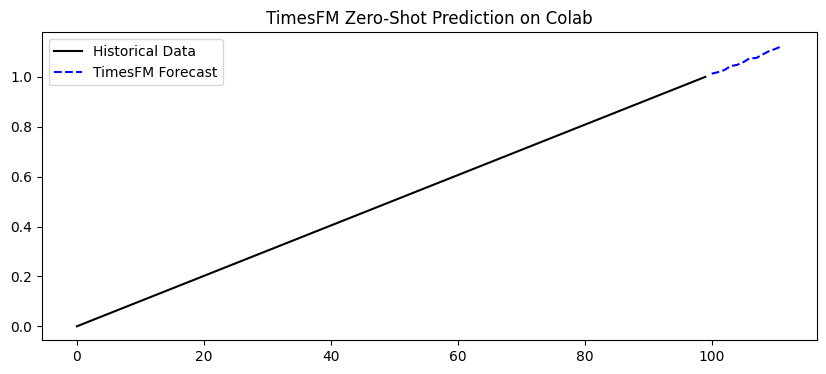

In [ ]:
import matplotlib.pyplot as plt

# Plotting the first series (Linear trend example)
history_len = len(series_1)
horizon_len = 12

plt.figure(figsize=(10, 4))
plt.plot(range(history_len), series_1, label="Historical Data", color="black")
plt.plot(range(history_len, history_len + horizon_len), point_forecast[0], label="TimesFM Forecast", color="blue", linestyle="--")
plt.title("TimesFM Zero-Shot Prediction on Colab")
plt.legend()
plt.show()

In [3]:
import pandas as pd
import timesfm
import numpy as np

# Dataset clásico de series temporales
df = pd.read_csv("air_passengers.csv")

# Pasajeros por mes
datos = df["Passengers"].tolist()

# Convertir datos a la estructura esperada por forecast (list of np.ndarray)
datos_for_forecast = [np.array(datos, dtype=np.float32)]

# Modelo de Google
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch",
    torch_compile=False # Set to True if you are running on a Colab GPU runtime for extra speed
)

# Configure the context and forecasting window
model.compile(
    timesfm.ForecastConfig(
        max_context=1024,             # Max historical data points the model looks at
        max_horizon=256,              # Max steps ahead the model will predict
        normalize_inputs=True,
        use_continuous_quantile_head=True
    )
)

# Predicción futura
point_forecast, quantile_forecast = model.forecast(inputs=datos_for_forecast, horizon=12)

# You can choose to print either the point forecast or quantile forecast
print("Point Forecast:")
print(point_forecast)
print("\nQuantile Forecast:")
print(quantile_forecast)

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

Point Forecast:
[[441.47986 406.12643 459.12393 480.0919  478.76056 537.17145 618.9755
  612.68964 518.9009  447.10925 388.4678  448.9761 ]]

Quantile Forecast:
[[[435.66327 420.85657 427.1673  432.901   438.2961  441.47986 442.4708
   446.9108  455.69434 457.8627 ]
  [408.8905  381.0256  390.90683 395.0481  402.0865  406.12643 408.99344
   412.59863 417.39478 429.2586 ]
  [458.8244  427.385   442.6335  449.37335 457.09988 459.12393 463.16238
   467.00662 471.25488 485.378  ]
  [471.40134 442.0084  459.5454  468.24594 472.75058 480.0919  488.22568
   490.8599  498.35992 512.7738 ]
  [482.0837  436.46927 453.0852  462.89792 469.76437 478.76056 487.00604
   489.4783  500.66684 516.2981 ]
  [539.52454 488.22626 509.19168 519.1382  529.8252  537.17145 543.9647
   554.7578  563.7738  583.48883]
  [616.84875 565.7429  591.2843  597.1513  610.05817 618.9755  625.3092
   637.737   647.02716 673.0114 ]
  [608.453   555.8307  585.4819  588.92163 604.18384 612.68964 621.6344
   633.4075  645.8002

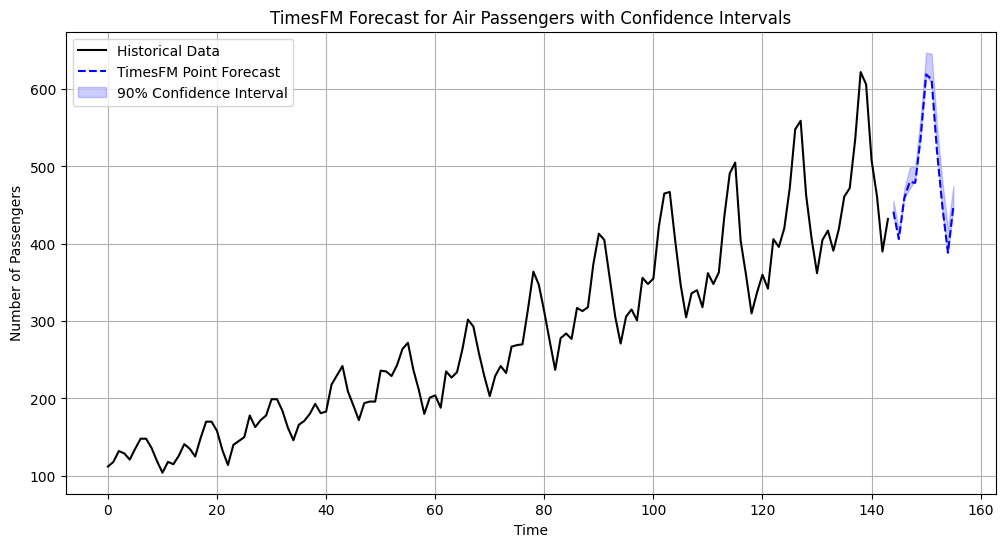

In [4]:
import matplotlib.pyplot as plt

# Get historical data length
history_len = len(datos)
# Horizon length is 12, as defined in the forecast call
horizon_len = 12

plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(range(history_len), datos, label="Historical Data", color="black")

# Plot point forecast
# The forecast starts after the historical data ends
forecast_x = range(history_len, history_len + horizon_len)
plt.plot(forecast_x, point_forecast[0], label="TimesFM Point Forecast", color="blue", linestyle="--")

# Plot confidence intervals (e.g., 10th and 90th percentiles)
# Assuming quantile_forecast has shape (num_series, horizon, num_quantiles)
# and the quantiles are ordered from lowest to highest.
# For 10 quantiles, the 10th percentile is at index 0 and 90th percentile is at index 8.
lower_bound = quantile_forecast[0, :, 0] # 10th percentile
upper_bound = quantile_forecast[0, :, 8] # 90th percentile

plt.fill_between(forecast_x, lower_bound, upper_bound, color='blue', alpha=0.2, label='90% Confidence Interval')

plt.title("TimesFM Forecast for Air Passengers with Confidence Intervals")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

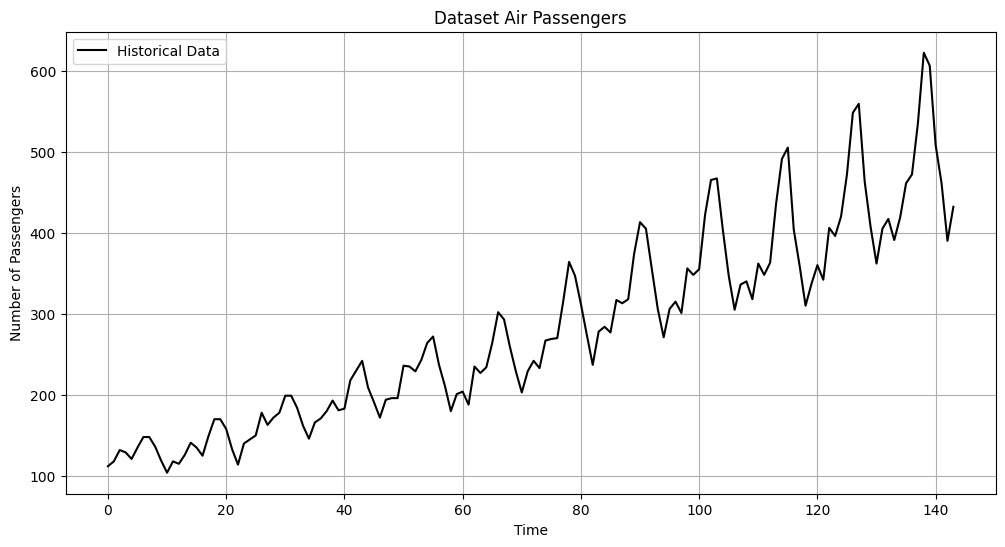

In [6]:
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(range(history_len), datos, label="Historical Data", color="black")

plt.title("Dataset Air Passengers")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()